In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
df = pd.read_csv('Spotify_weeklytop200_cleaned.csv')

In [4]:
STAGE_ORDER = ['Stage 1 (2017-2019)', 'Stage 2 (2020-2022)', 'Stage 3 (2023-2025)']
STAGE_LABELS = ['Pre-pandemic\n(2017-2019)', 'Pandemic\n(2020-2022)', 'Post-pandemic\n(2023-2025)']
COLORS = ['#4C9BE8', '#E8834C', '#4CE8A0']
df['Stage'] = pd.Categorical(df['Stage'], categories=STAGE_ORDER, ordered=True)

## Sample size per stage

In [5]:
counts       = df['Stage'].value_counts().sort_index()
weeks        = df.groupby('Stage', observed=True)['Week_Label'].nunique().sort_index()
unique_songs = df.groupby('Stage', observed=True)['id'].nunique().sort_index()
 
summary = pd.DataFrame({
    'Total Rows'  : counts.values,
    'Unique Weeks': weeks.values,
    'Unique Songs': unique_songs.values
}, index=STAGE_LABELS)
print('Sample Size per Stage')
print(summary.to_string())

Sample Size per Stage
                            Total Rows  Unique Weeks  Unique Songs
Pre-pandemic\n(2017-2019)        31217           156          3149
Pandemic\n(2020-2022)            31425           157          3170
Post-pandemic\n(2023-2025)       29067           157          2179


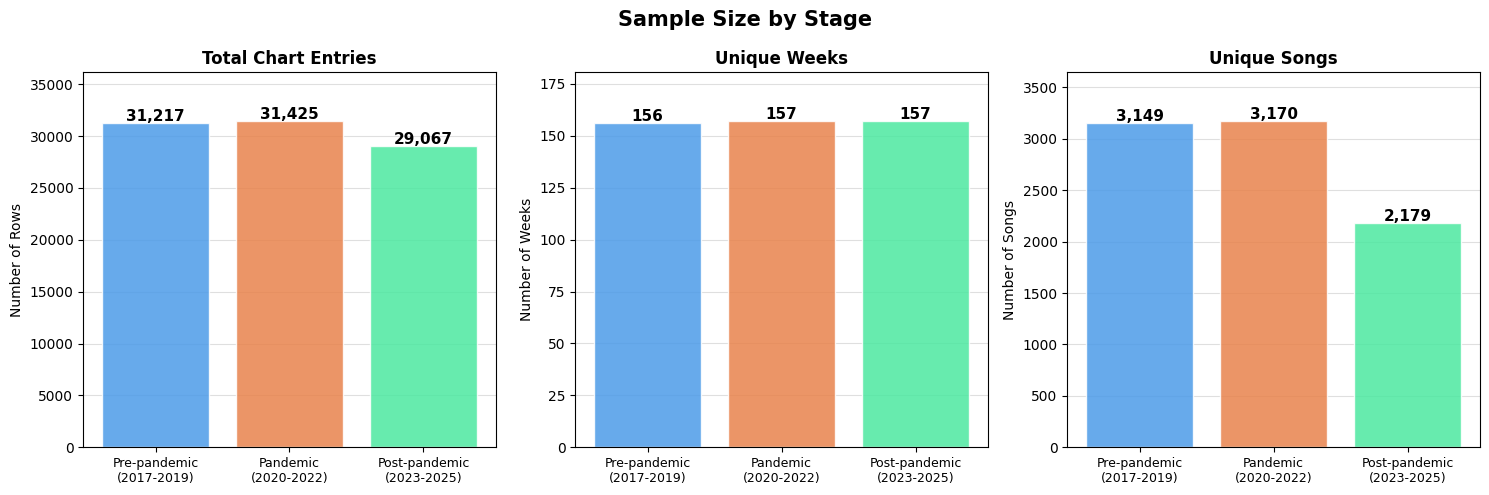

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
 
# Plot 1: total rows
axes[0].bar(STAGE_LABELS, counts.values, color=COLORS, alpha=0.85, edgecolor='white')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('Total Chart Entries', fontweight='bold')
axes[0].set_ylabel('Number of Rows')
axes[0].set_ylim(0, max(counts.values) * 1.15)
 
# Plot 2: unique weeks
axes[1].bar(STAGE_LABELS, weeks.values, color=COLORS, alpha=0.85, edgecolor='white')
for i, v in enumerate(weeks.values):
    axes[1].text(i, v + 1, f'{v}', ha='center', fontweight='bold', fontsize=11)
axes[1].set_title('Unique Weeks', fontweight='bold')
axes[1].set_ylabel('Number of Weeks')
axes[1].set_ylim(0, max(weeks.values) * 1.15)
 
# Plot 3: unique songs
axes[2].bar(STAGE_LABELS, unique_songs.values, color=COLORS, alpha=0.85, edgecolor='white')
for i, v in enumerate(unique_songs.values):
    axes[2].text(i, v + 20, f'{v:,}', ha='center', fontweight='bold', fontsize=11)
axes[2].set_title('Unique Songs', fontweight='bold')
axes[2].set_ylabel('Number of Songs')
axes[2].set_ylim(0, max(unique_songs.values) * 1.15)
 
for ax in axes:
    ax.tick_params(axis='x', labelsize=9)
    ax.grid(axis='y', alpha=0.4)
    ax.set_axisbelow(True)
 
fig.suptitle('Sample Size by Stage', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### Summary Statistics (mean, std, skewness, kurtosis) by Stage

In [7]:
FEATURES     = ['Danceability', 'Energy', 'Loudness', 'Speechiness',
                'Acousticness', 'Instrumentalness', 'Valence']

In [8]:
print("Summary Statistics by Stage")

for stage, label in zip(STAGE_ORDER, ['Pre-pandemic', 'Pandemic', 'Post-pandemic']):
    subset = df[df['Stage'] == stage][FEATURES]
    stats = pd.DataFrame({
        'Mean'    : subset.mean(),
        'Std'     : subset.std(),
        'Min'     : subset.min(),
        'Max'     : subset.max(),
        'Skewness': subset.skew(),
        'Kurtosis': subset.kurt()
    }).round(3)
    print(f"--- {label} ---")
    print(stats.to_string())
    print()

Summary Statistics by Stage
--- Pre-pandemic ---
                   Mean    Std     Min    Max  Skewness  Kurtosis
Danceability      0.699  0.131   0.153  0.974    -0.656     0.493
Energy            0.641  0.159   0.005  0.980    -0.473    -0.115
Loudness         -6.023  2.324 -23.023 -0.777    -1.497     4.784
Speechiness       0.117  0.104   0.023  0.966     1.776     3.253
Acousticness      0.217  0.224   0.000  0.994     1.345     1.143
Instrumentalness  0.007  0.050   0.000  0.942    10.548   138.447
Valence           0.495  0.217   0.036  0.982     0.085    -0.822

--- Pandemic ---
                   Mean    Std     Min    Max  Skewness  Kurtosis
Danceability      0.680  0.145   0.150  0.985    -0.593    -0.219
Energy            0.632  0.162   0.022  0.990    -0.503    -0.080
Loudness         -6.212  2.404 -31.160 -0.484    -1.249     3.330
Speechiness       0.104  0.096   0.023  0.894     1.827     3.186
Acousticness      0.259  0.257   0.000  0.994     1.045     0.049
Instrumen

In [9]:
print("--- Overall (all stages) ---")
overall = pd.DataFrame({
    'Mean'    : df[FEATURES].mean(),
    'Std'     : df[FEATURES].std(),
    'Skewness': df[FEATURES].skew(),
    'Kurtosis': df[FEATURES].kurt()
}).round(3)
print(overall.to_string())

--- Overall (all stages) ---
                   Mean    Std  Skewness  Kurtosis
Danceability      0.674  0.144    -0.557    -0.006
Energy            0.637  0.164    -0.524     0.056
Loudness         -6.294  2.843    -3.849    37.435
Speechiness       0.099  0.093     2.075     4.621
Acousticness      0.244  0.249     1.142     0.339
Instrumentalness  0.013  0.078     8.337    77.482
Valence           0.505  0.229     0.046    -0.878


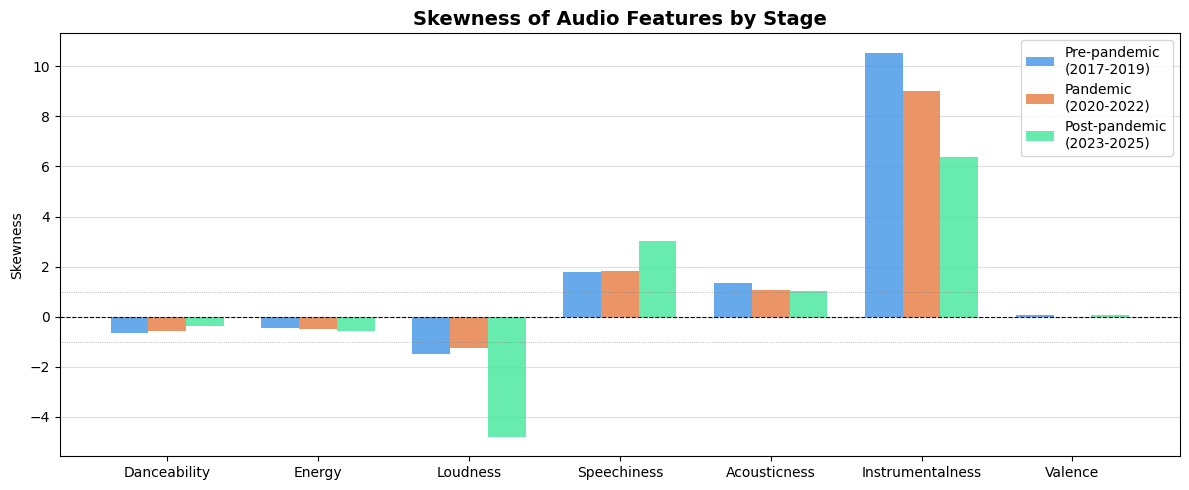

In [10]:
skew_data = df.groupby('Stage', observed=True)[FEATURES].apply(lambda x: x.skew())

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(FEATURES))
width = 0.25
colors = ['#4C9BE8', '#E8834C', '#4CE8A0']

for i, (stage, color, label) in enumerate(zip(STAGE_ORDER, colors, STAGE_LABELS)):
    ax.bar(x + i * width, skew_data.loc[stage], width, label=label, color=color, alpha=0.85)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.axhline(1, color='gray', linewidth=0.6, linestyle=':', alpha=0.7)
ax.axhline(-1, color='gray', linewidth=0.6, linestyle=':', alpha=0.7)
ax.set_xticks(x + width)
ax.set_xticklabels(FEATURES, fontsize=10)
ax.set_ylabel('Skewness')
ax.set_title('Skewness of Audio Features by Stage', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## Audio Feature by Stage

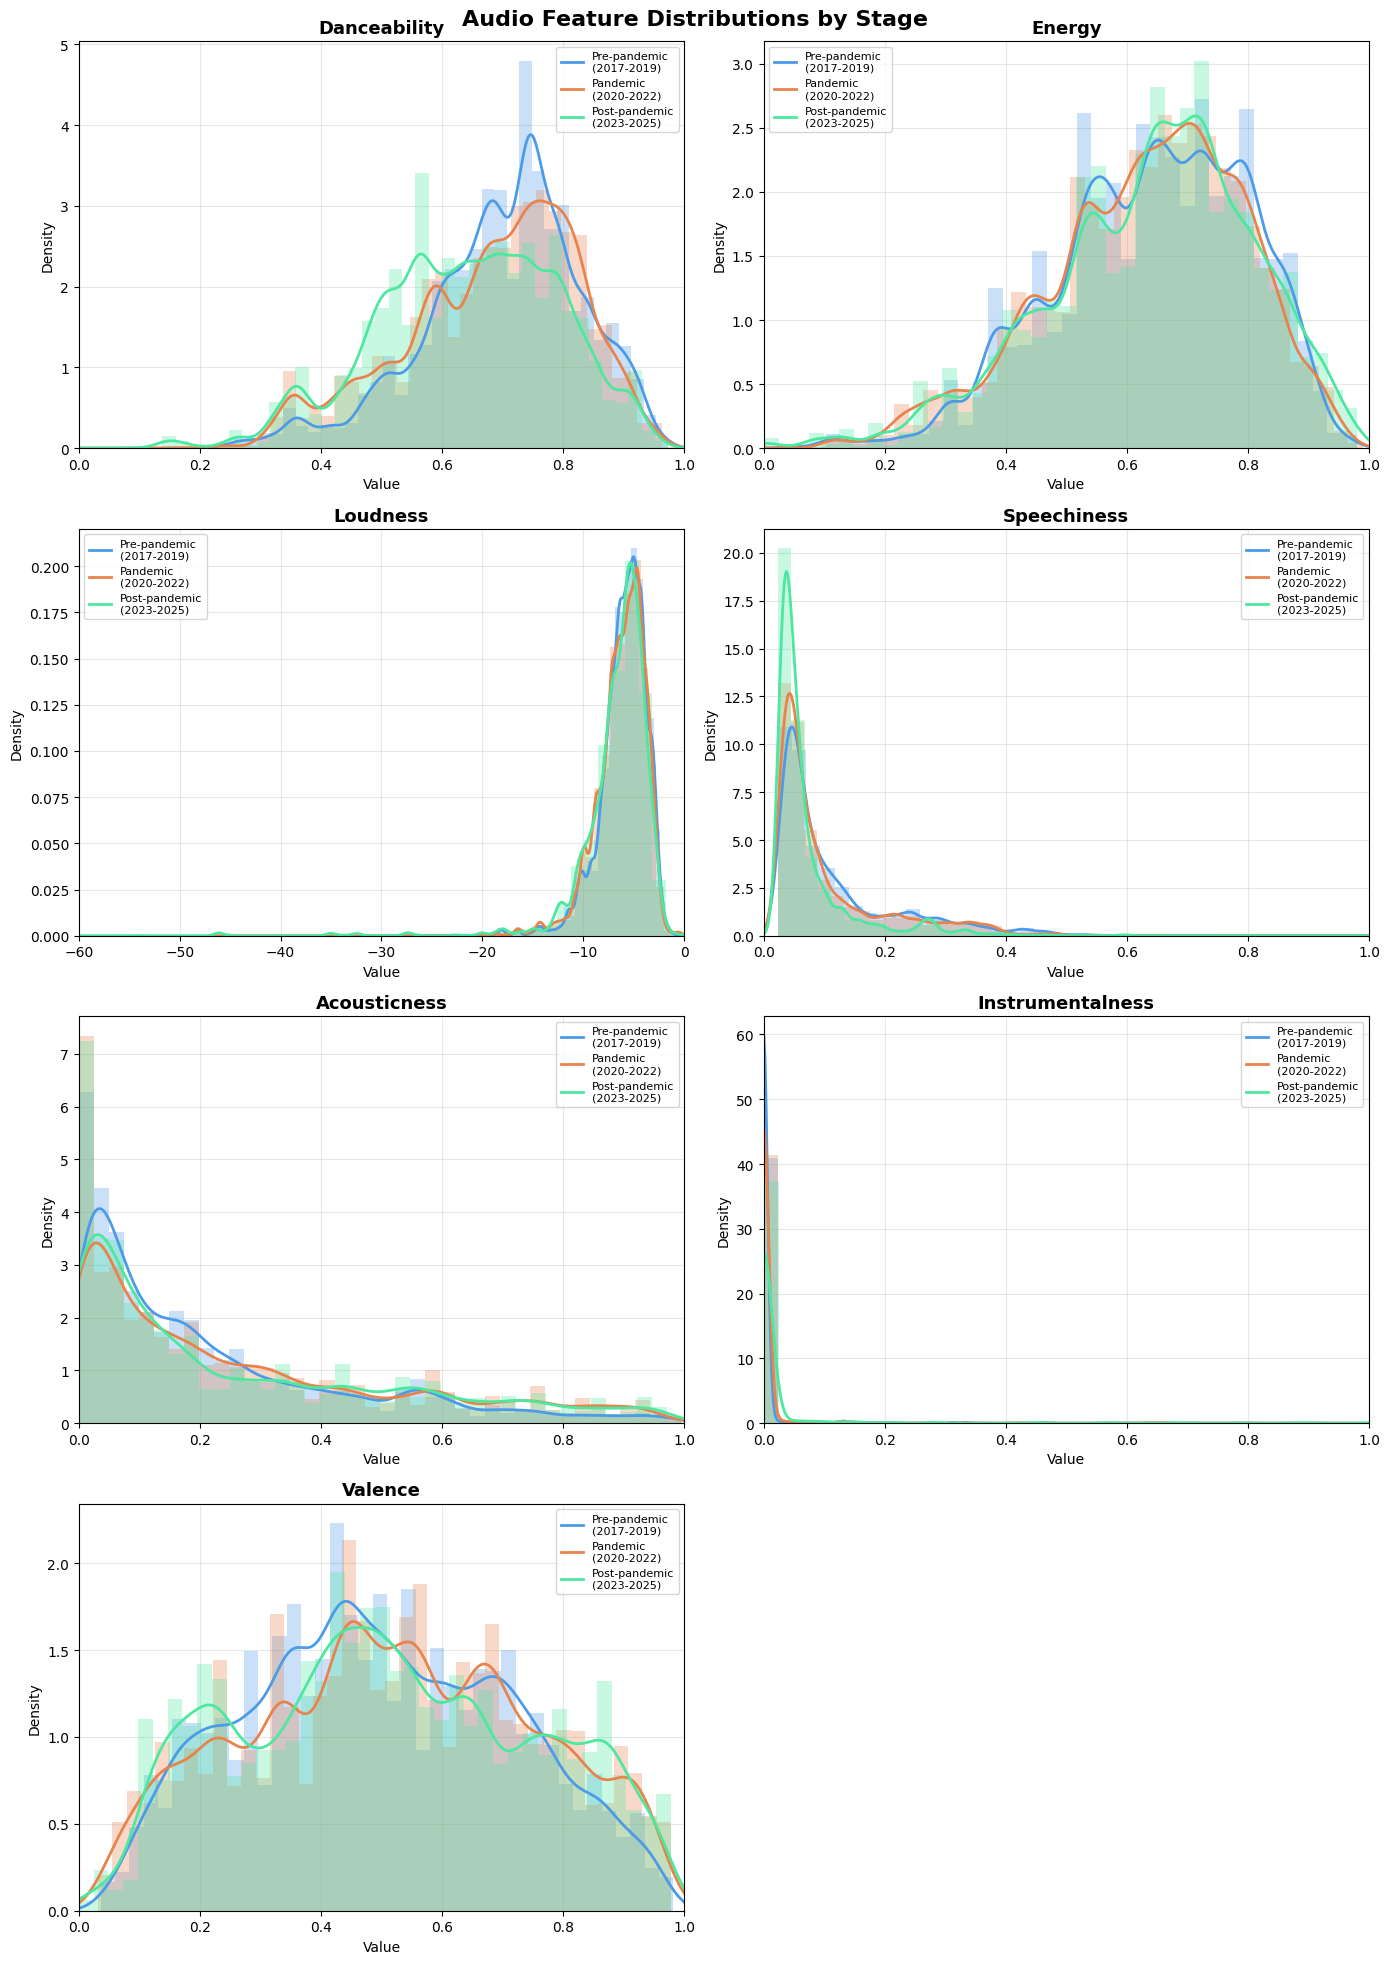

In [11]:
XLIMS = {
    'Danceability'    : (0, 1),
    'Energy'          : (0, 1),
    'Loudness'        : (-60, 0),
    'Speechiness'     : (0, 1),
    'Acousticness'    : (0, 1),
    'Instrumentalness': (0, 1),
    'Valence'         : (0, 1),
}
fig, axes = plt.subplots(4, 2, figsize=(14, 20))
axes = axes.flatten()

for i, feature in enumerate(FEATURES):
    ax = axes[i]
    for stage, color, label in zip(STAGE_ORDER, COLORS, STAGE_LABELS):
        data = df[df['Stage'] == stage][feature].dropna()
        ax.hist(data, bins=40, alpha=0.3, color=color, density=True)
        data.plot.kde(ax=ax, color=color, linewidth=2, label=label)
    ax.set_title(feature, fontweight='bold', fontsize=13)
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.set_xlim(XLIMS[feature])
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.set_axisbelow(True)

# hide the last unused subplot
axes[-1].set_visible(False)

fig.suptitle('Audio Feature Distributions by Stage', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Boxplot by Stage

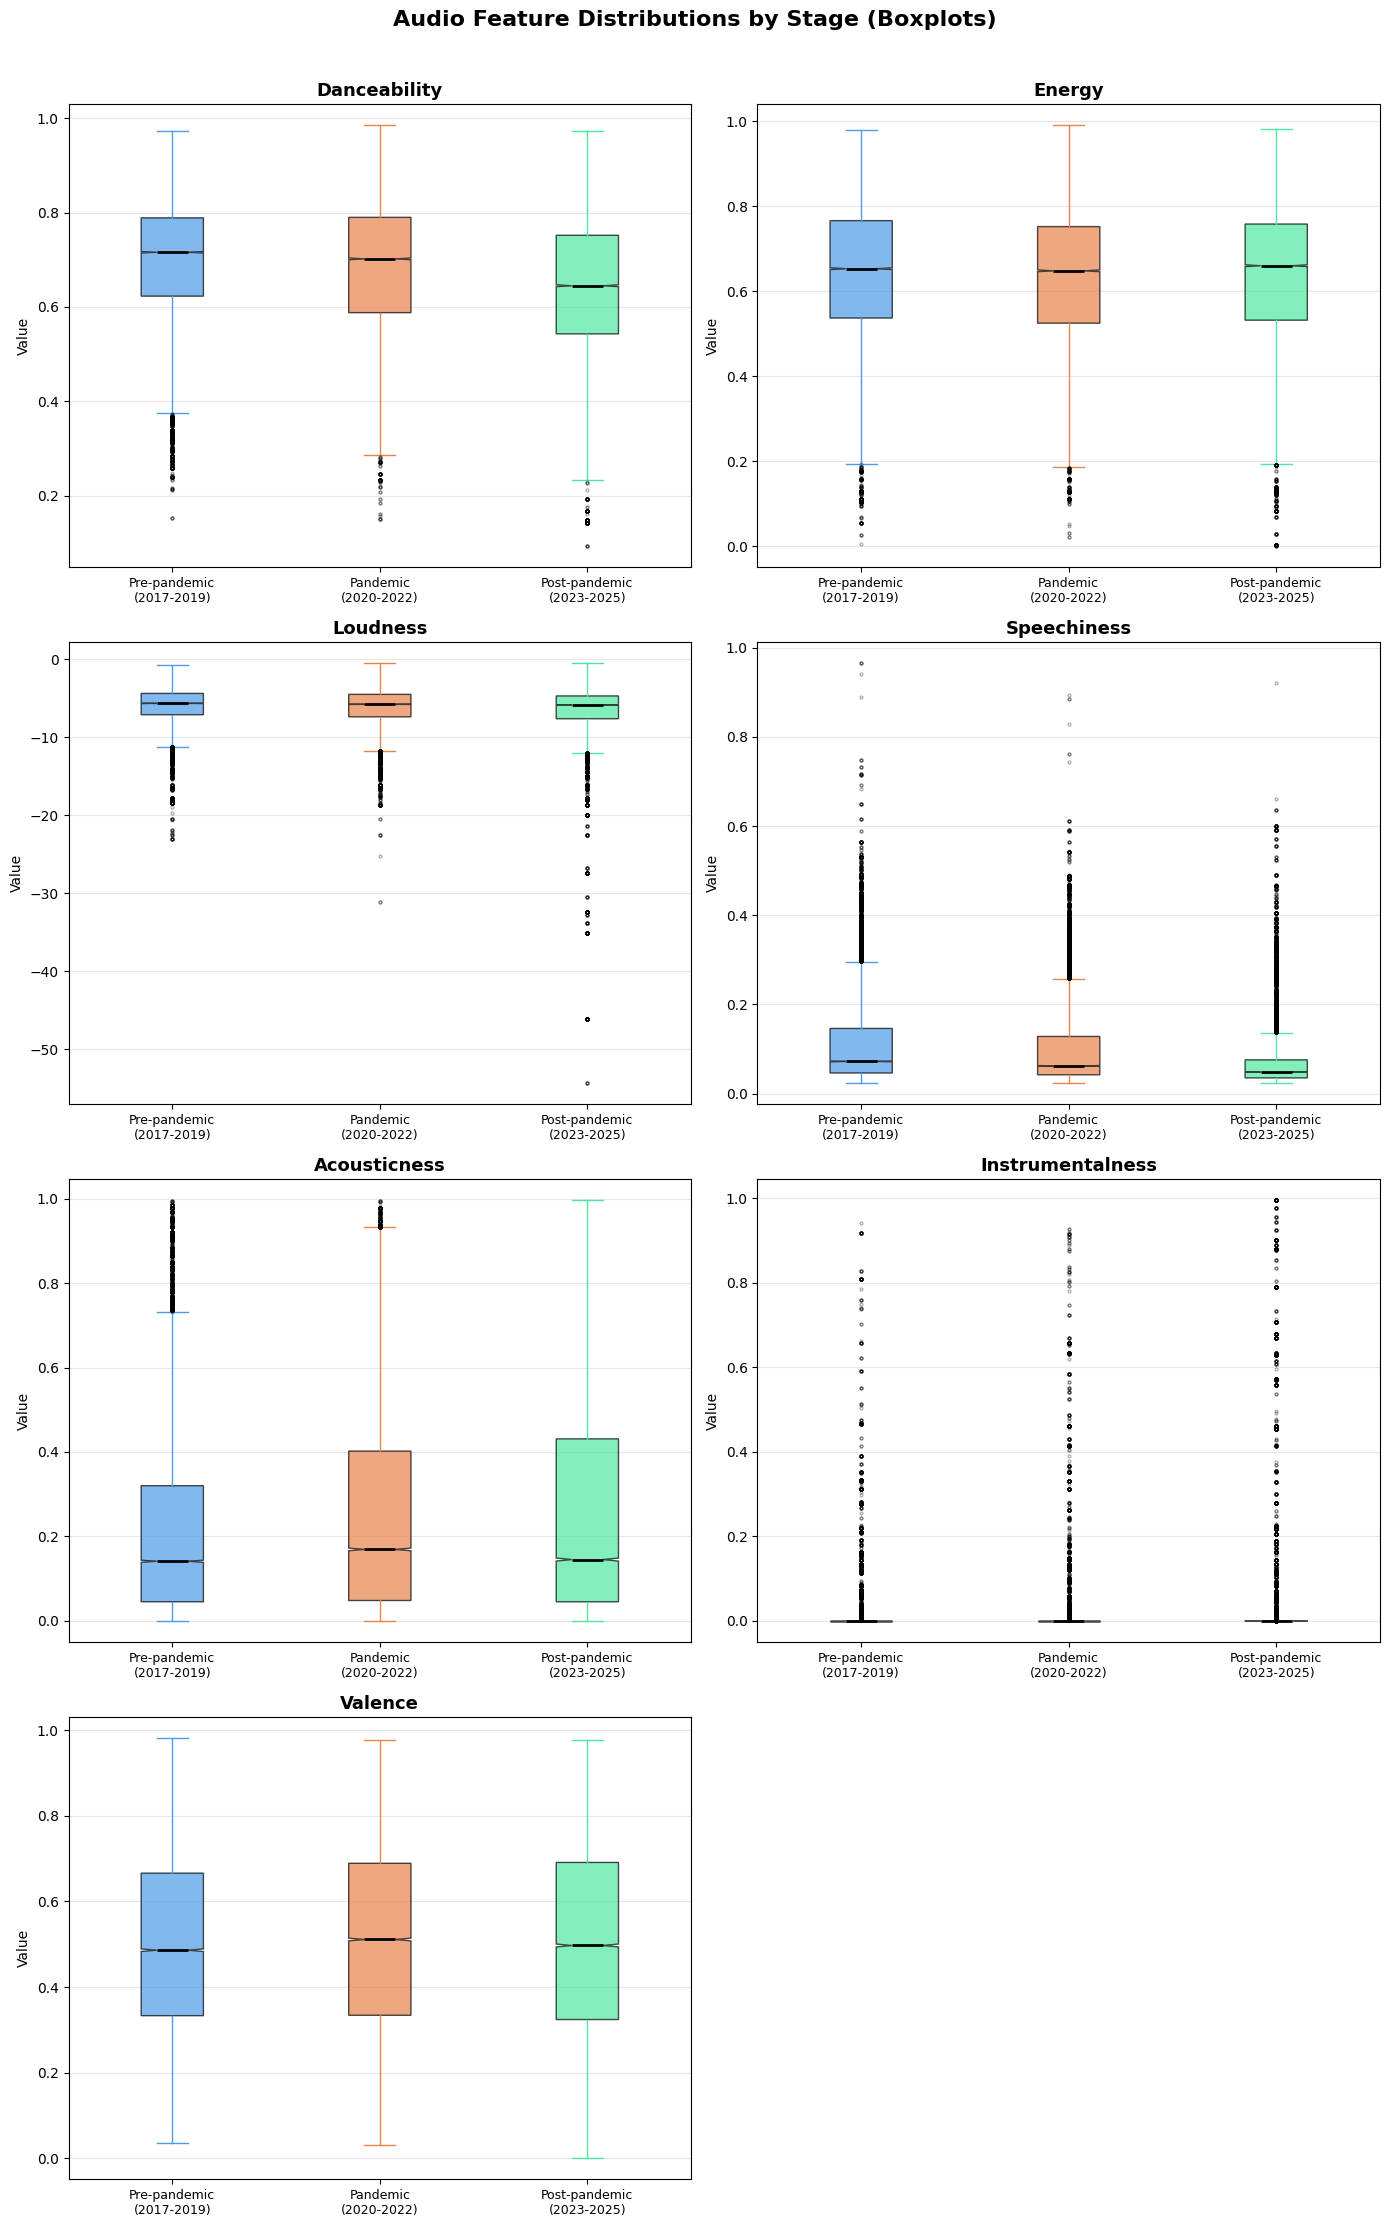

In [12]:
fig, axes = plt.subplots(4, 2, figsize=(14, 22))
axes = axes.flatten()

for i, feature in enumerate(FEATURES):
    ax = axes[i]
    data_by_stage = [df[df['Stage'] == stage][feature].dropna().values
                     for stage in STAGE_ORDER]

    bp = ax.boxplot(data_by_stage,
                    patch_artist=True,
                    notch=True,
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='o', markersize=2, alpha=0.3))

    for patch, color in zip(bp['boxes'], COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    # color whiskers and caps to match boxes
    for j, (whisker, cap) in enumerate(zip(bp['whiskers'], bp['caps'])):
        color = COLORS[j // 2]
        whisker.set_color(color)
        cap.set_color(color)

    ax.set_title(feature, fontweight='bold', fontsize=13)
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(STAGE_LABELS, fontsize=9)
    ax.set_ylabel('Value')
    ax.grid(axis='y', alpha=0.3)
    ax.set_axisbelow(True)

axes[-1].set_visible(False)

fig.suptitle('Audio Feature Distributions by Stage (Boxplots)',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [13]:
median_table = df.groupby('Stage', observed=True)[FEATURES].median().round(3)
median_table.index = ['Pre-pandemic', 'Pandemic', 'Post-pandemic']
print('Median by Stage')
print(median_table.to_string())

Median by Stage
               Danceability  Energy  Loudness  Speechiness  Acousticness  Instrumentalness  Valence
Pre-pandemic          0.716   0.653    -5.675        0.072         0.141               0.0    0.486
Pandemic              0.702   0.648    -5.795        0.062         0.169               0.0    0.511
Post-pandemic         0.645   0.660    -5.905        0.048         0.145               0.0    0.497


In [14]:
iqr_table = df.groupby('Stage', observed=True)[FEATURES].apply(
    lambda x: x.quantile(0.75) - x.quantile(0.25)
).round(3)
iqr_table.index = ['Pre-pandemic', 'Pandemic', 'Post-pandemic']
print('QR by Stage')
print(iqr_table.to_string())

QR by Stage
               Danceability  Energy  Loudness  Speechiness  Acousticness  Instrumentalness  Valence
Pre-pandemic          0.166   0.229     2.733        0.100         0.275               0.0    0.333
Pandemic              0.202   0.227     2.877        0.086         0.354               0.0    0.355
Post-pandemic         0.209   0.226     2.920        0.040         0.386               0.0    0.367


## Mean Bar Chart by Stage

In [15]:
mean_table = df.groupby('Stage', observed=True)[FEATURES].mean().round(3)
mean_table.index = ['Pre-pandemic', 'Pandemic', 'Post-pandemic']
print('Mean by Stage')
print(mean_table.to_string())

df_plot = df.copy()
df_plot['Loudness_norm'] = (df['Loudness'] - df['Loudness'].min()) / \
                            (df['Loudness'].max() - df['Loudness'].min())
plot_features = [f for f in FEATURES if f != 'Loudness'] + ['Loudness_norm']

means = df_plot.groupby('Stage', observed=True)[plot_features].mean()

Mean by Stage
               Danceability  Energy  Loudness  Speechiness  Acousticness  Instrumentalness  Valence
Pre-pandemic          0.699   0.641    -6.023        0.117         0.217             0.007    0.495
Pandemic              0.680   0.632    -6.212        0.104         0.259             0.010    0.513
Post-pandemic         0.640   0.639    -6.674        0.074         0.256             0.022    0.508


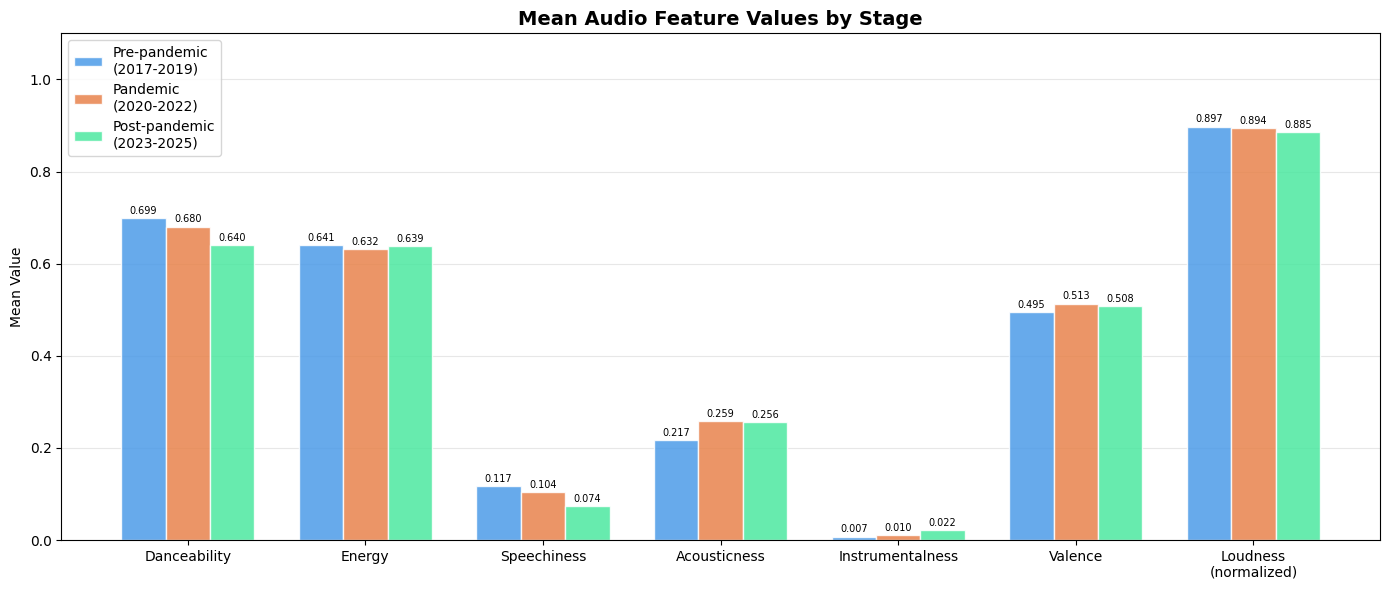

In [16]:
fig, ax = plt.subplots(figsize=(14, 6))
x     = np.arange(len(plot_features))
width = 0.25

for i, (stage, color, label) in enumerate(zip(STAGE_ORDER, COLORS, STAGE_LABELS)):
    bars = ax.bar(x + i * width, means.loc[stage], width,
                  label=label, color=color, alpha=0.85, edgecolor='white')
    # add value labels on top of each bar
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 0.005,
                f'{height:.3f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x + width)
ax.set_xticklabels(
    [f.replace('_norm', '\n(normalized)') for f in plot_features],
    fontsize=10
)
ax.set_ylabel('Mean Value')
ax.set_ylim(0, 1.1)
ax.set_title("Mean Audio Feature Values by Stage",
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## Mean Audio Feature Values by Year

In [17]:
yearly = df.groupby('Year')[FEATURES].mean().reset_index()

print("Mean Audio Feature Values by Stage")
print(yearly.round(3).to_string(index=False))

Mean Audio Feature Values by Stage
 Year  Danceability  Energy  Loudness  Speechiness  Acousticness  Instrumentalness  Valence
 2017         0.693   0.656    -5.908        0.112         0.187             0.007    0.506
 2018         0.703   0.644    -5.999        0.116         0.208             0.005    0.482
 2019         0.702   0.623    -6.162        0.123         0.256             0.011    0.497
 2020         0.703   0.615    -6.265        0.120         0.260             0.009    0.515
 2021         0.675   0.630    -6.193        0.099         0.271             0.009    0.524
 2022         0.664   0.650    -6.180        0.094         0.245             0.012    0.500
 2023         0.656   0.643    -6.290        0.081         0.257             0.015    0.507
 2024         0.639   0.638    -6.530        0.072         0.248             0.017    0.508
 2025         0.624   0.635    -7.221        0.069         0.265             0.035    0.508


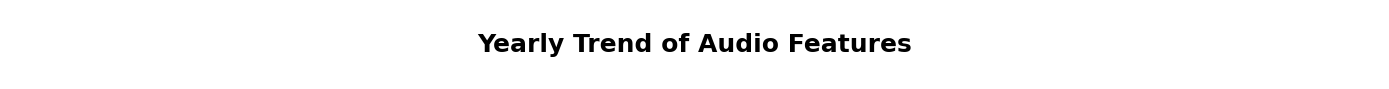

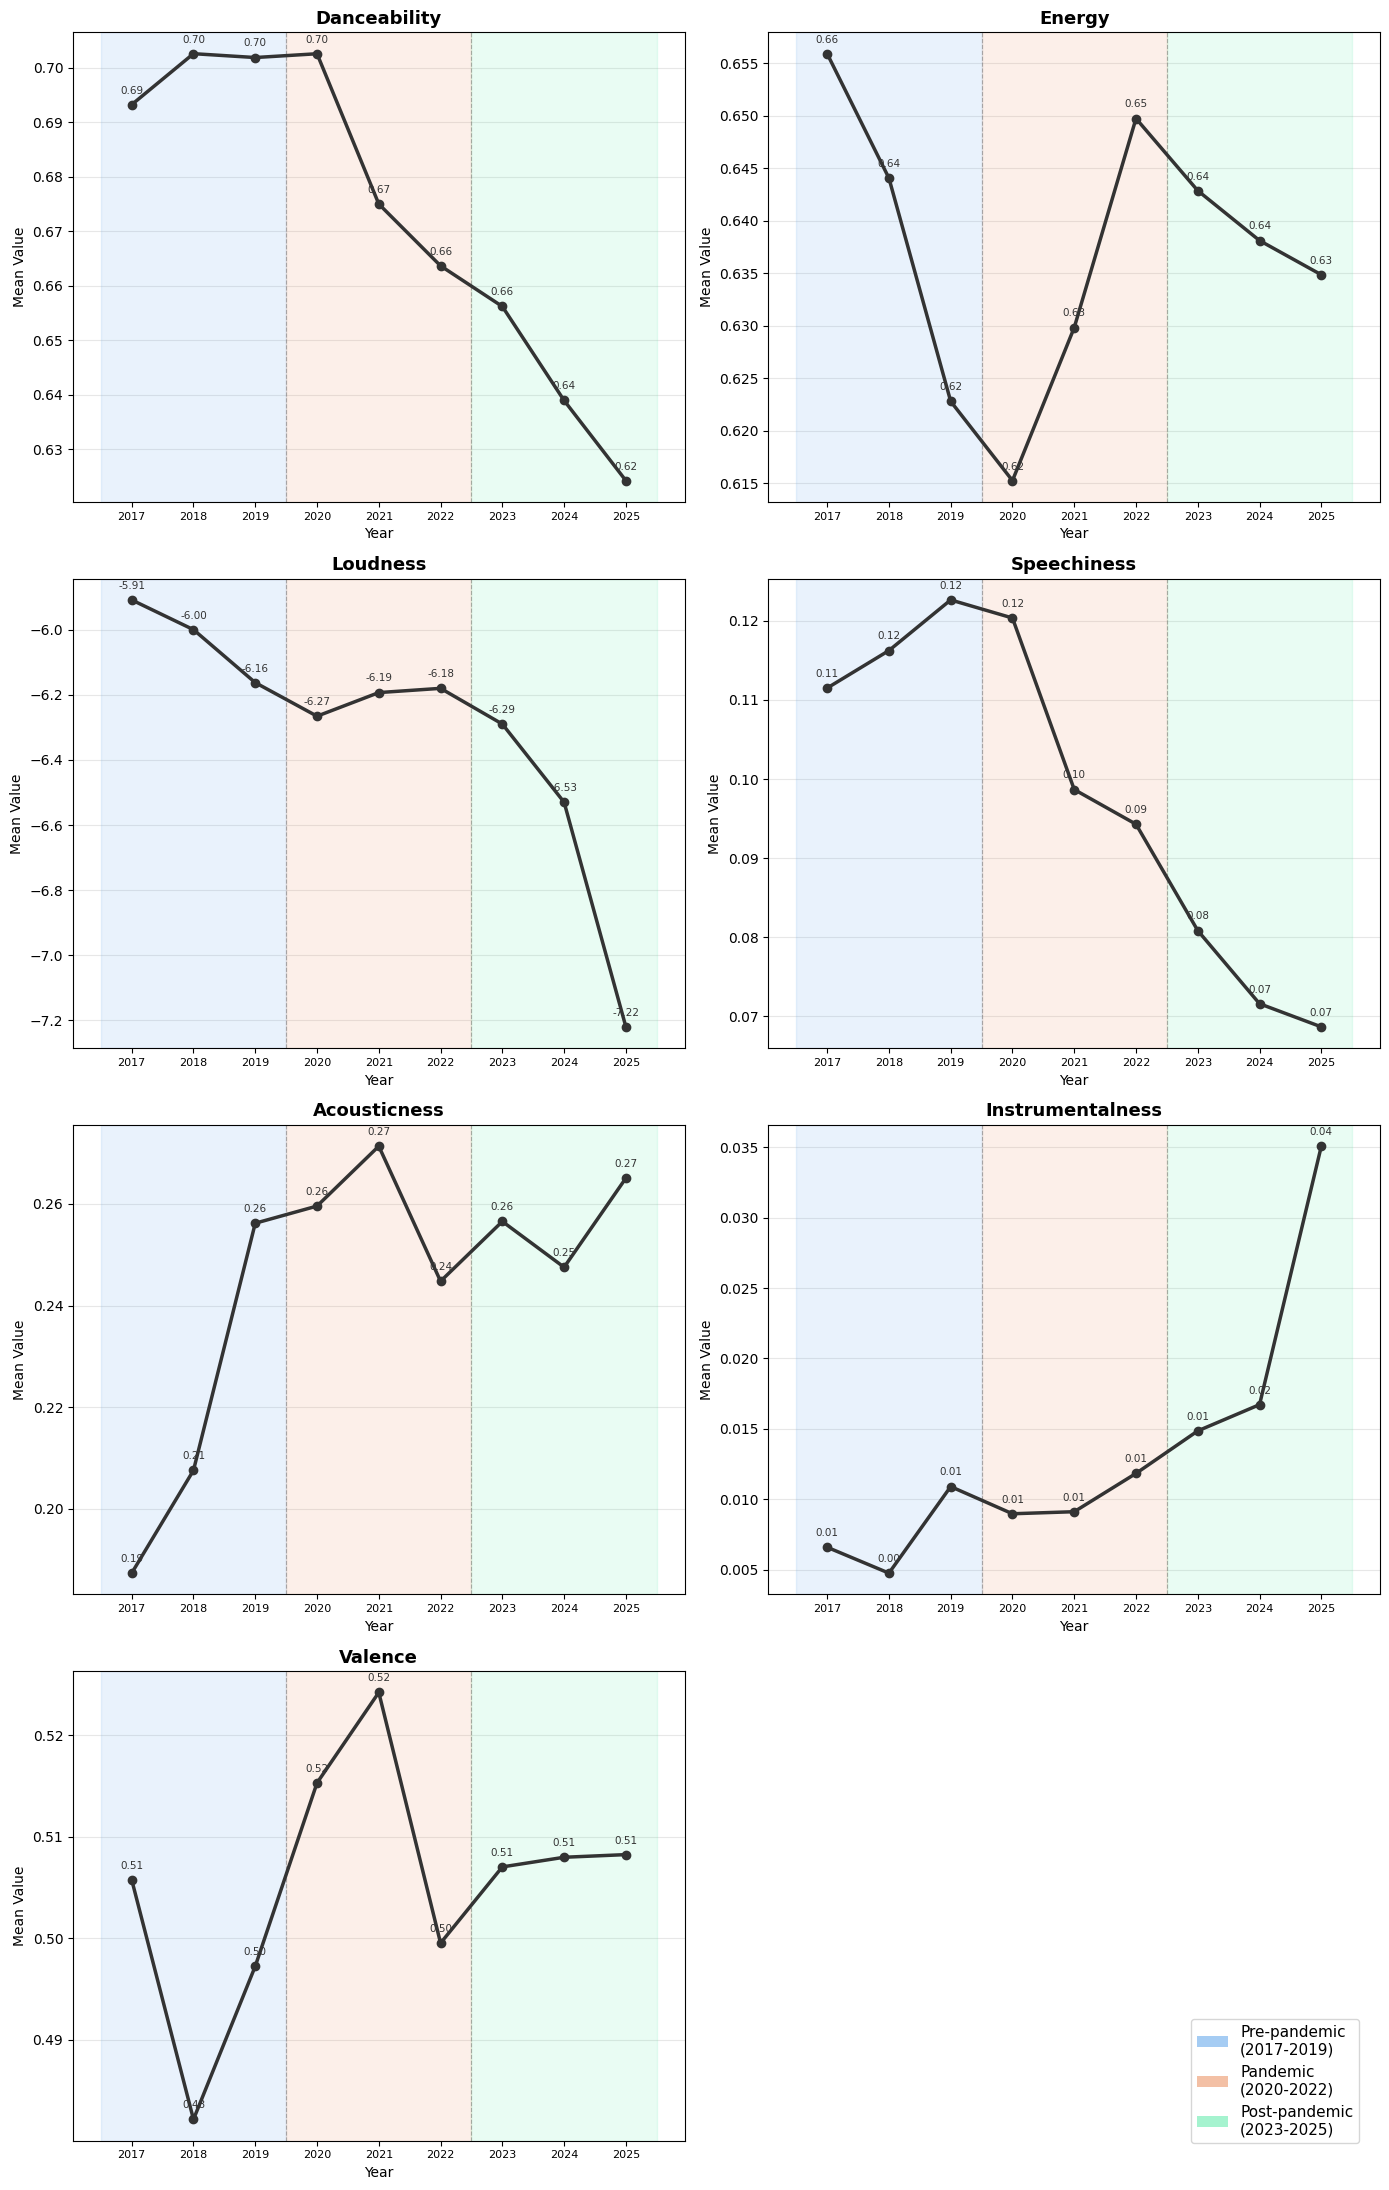

In [25]:
import matplotlib.ticker as ticker
from matplotlib.patches import Patch
stage_ranges = [(2017, 2019), (2020, 2022), (2023, 2025)]
fig_title, ax_title = plt.subplots(figsize=(14, 1))
ax_title.text(0.5, 0.5, 'Yearly Trend of Audio Features',
              ha='center', va='center', fontsize=18, fontweight='bold',
              transform=ax_title.transAxes)
ax_title.axis('off')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(4, 2, figsize=(14, 22))
axes = axes.flatten()

for i, feature in enumerate(FEATURES):
    ax = axes[i]
    for (start, end), color in zip(stage_ranges, COLORS):
        ax.axvspan(start - 0.5, end + 0.5, alpha=0.12, color=color)
    ax.axvline(x=2019.5, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)
    ax.axvline(x=2022.5, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)
    ax.plot(yearly['Year'], yearly[feature],
            color='#333333', linewidth=2.5, marker='o', markersize=6)
    for _, row in yearly.iterrows():
        ax.annotate(f"{row[feature]:.2f}",
                    xy=(row['Year'], row[feature]),
                    xytext=(0, 8), textcoords='offset points',
                    ha='center', fontsize=7.5, color='#333333')
    ax.set_title(feature, fontweight='bold', fontsize=13)
    ax.set_xlabel('Year')
    ax.set_ylabel('Mean Value')
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.tick_params(axis='x', labelsize=8)
    ax.grid(axis='y', alpha=0.3)
    ax.set_axisbelow(True)

# hide last spare subplot completely
fig.delaxes(axes[-1])

# add legend to figure level instead
legend_elements = [Patch(facecolor=c, alpha=0.5, label=l)
                   for c, l in zip(COLORS, STAGE_LABELS)]
fig.legend(handles=legend_elements, loc='lower right',
           fontsize=11, frameon=True, bbox_to_anchor=(0.98, 0.02))

plt.tight_layout()
plt.show()


## Correlation Heatmap by Stage

=== Correlation Matrix: Pre-pandemic ===
                  Danceability  Energy  Loudness  Speechiness  Acousticness  Instrumentalness  Valence
Danceability             1.000   0.039     0.121        0.178        -0.195            -0.024    0.322
Energy                   0.039   1.000     0.750       -0.046        -0.471            -0.070    0.382
Loudness                 0.121   0.750     1.000       -0.151        -0.376            -0.149    0.347
Speechiness              0.178  -0.046    -0.151        1.000        -0.057            -0.016   -0.003
Acousticness            -0.195  -0.471    -0.376       -0.057         1.000             0.070   -0.046
Instrumentalness        -0.024  -0.070    -0.149       -0.016         0.070             1.000   -0.084
Valence                  0.322   0.382     0.347       -0.003        -0.046            -0.084    1.000

=== Correlation Matrix: Pandemic ===
                  Danceability  Energy  Loudness  Speechiness  Acousticness  Instrumentalness  Va

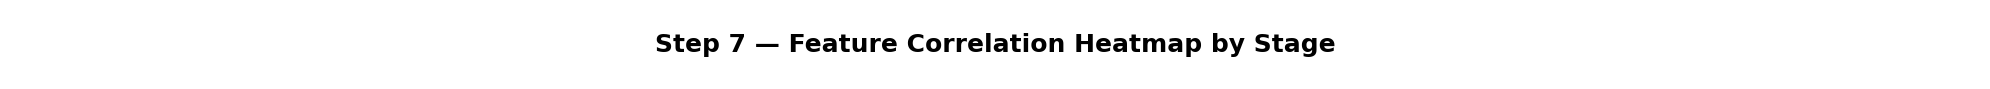

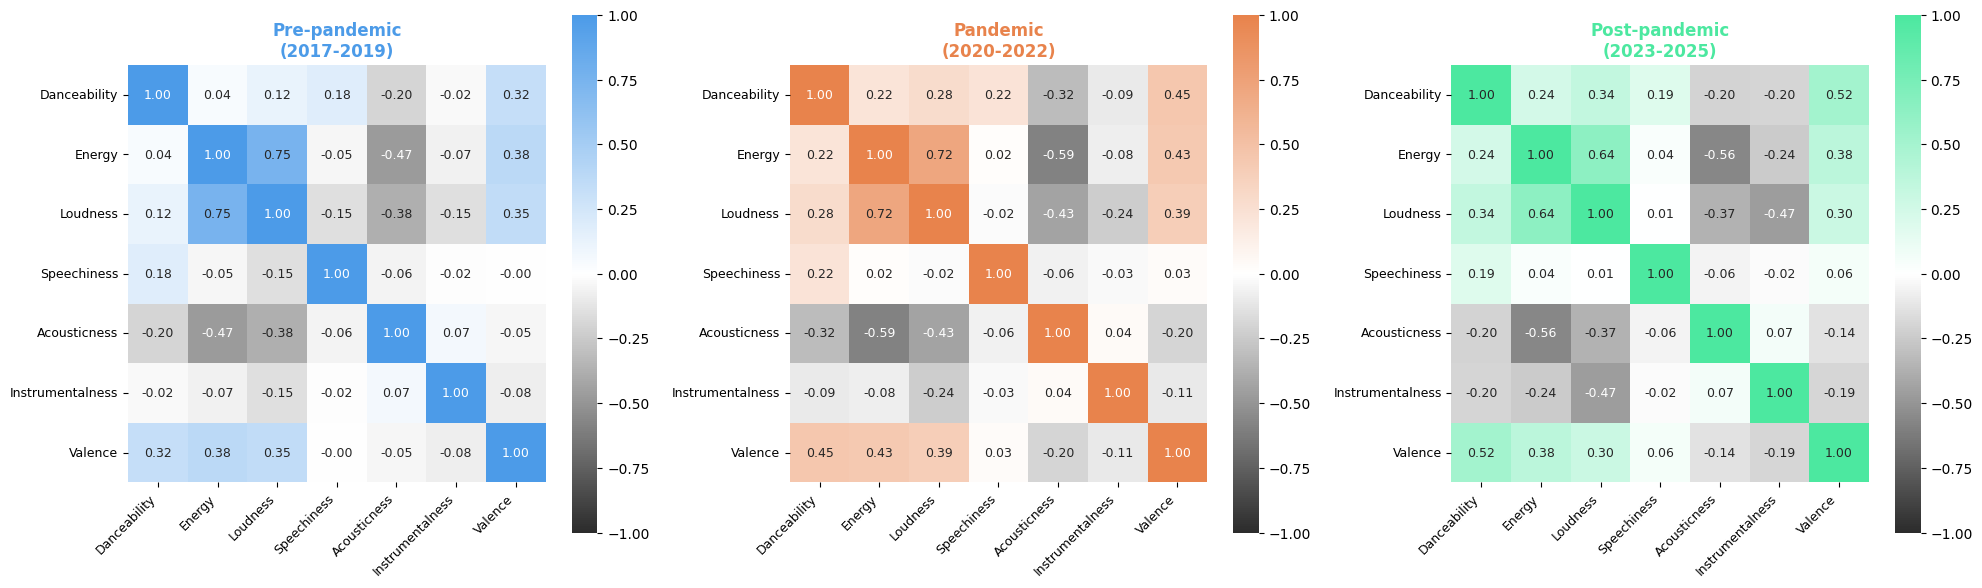

In [28]:
from matplotlib.colors import LinearSegmentedColormap
for stage, label in zip(STAGE_ORDER, ['Pre-pandemic', 'Pandemic', 'Post-pandemic']):
    print(f"=== Correlation Matrix: {label} ===")
    corr = df[df['Stage'] == stage][FEATURES].corr().round(3)
    print(corr.to_string())
    print()

# ── Separate title ────────────────────────────────────────────────────────────
fig_title, ax_title = plt.subplots(figsize=(20, 1))
ax_title.text(0.5, 0.5, 'Step 7 — Feature Correlation Heatmap by Stage',
              ha='center', va='center', fontsize=18, fontweight='bold',
              transform=ax_title.transAxes)
ax_title.axis('off')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, stage, label, color in zip(axes, STAGE_ORDER, STAGE_LABELS, COLORS):
    cmap = LinearSegmentedColormap.from_list(
        'stage_cmap', ['#2c2c2c', 'white', color]
    )
    corr = df[df['Stage'] == stage][FEATURES].corr()
    sns.heatmap(corr,
                ax=ax,
                annot=True,
                fmt='.2f',
                cmap=cmap,
                center=0,
                vmin=-1, vmax=1,
                annot_kws={'size': 9},
                square=True,
                cbar=True)
    ax.set_title(label, fontweight='bold', fontsize=12, color=color)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.show()


In [29]:
print('Top 10 Songs per Stage')
for stage, label in zip(STAGE_ORDER, ['Pre-pandemic', 'Pandemic', 'Post-pandemic']):
    top_songs = (df[df['Stage'] == stage]
                 .groupby(['Title', 'Artists_All'])['Week_Label']
                 .nunique()
                 .reset_index()
                 .rename(columns={'Week_Label': 'Weeks_Charted'})
                 .sort_values('Weeks_Charted', ascending=False)
                 .head(10))
    print(f"--- {label} ---")
    print(top_songs.to_string(index=False))
    print()

# ── Top 10 artists per stage (by total weeks charted) ─────────────────────────
print("=== Top 10 Artists per Stage ===\n")
for stage, label in zip(STAGE_ORDER, ['Pre-pandemic', 'Pandemic', 'Post-pandemic']):
    top_artists = (df[df['Stage'] == stage]
                   .groupby('Artists_All')['Week_Label']
                   .nunique()
                   .reset_index()
                   .rename(columns={'Week_Label': 'Weeks_Charted'})
                   .sort_values('Weeks_Charted', ascending=False)
                   .head(10))
    print(f"--- {label} ---")
    print(top_artists.to_string(index=False))
    print()

Top 10 Songs per Stage
--- Pre-pandemic ---
               Title              Artists_All  Weeks_Charted
        Shape of You               Ed Sheeran            156
Say You Won't Let Go             James Arthur            155
            Believer          Imagine Dragons            152
             Perfect               Ed Sheeran            147
              Closer The Chainsmokers, Halsey            138
             Thunder          Imagine Dragons            136
    I Like Me Better                     Lauv            132
          Photograph               Ed Sheeran            123
     Congratulations       Post Malone, Quavo            120
          goosebumps             Travis Scott            118

--- Pandemic ---
                                        Title           Artists_All  Weeks_Charted
                             Watermelon Sugar          Harry Styles            157
                              Blinding Lights            The Weeknd            157
                  

## Top 10 Songs & Artists by Stage

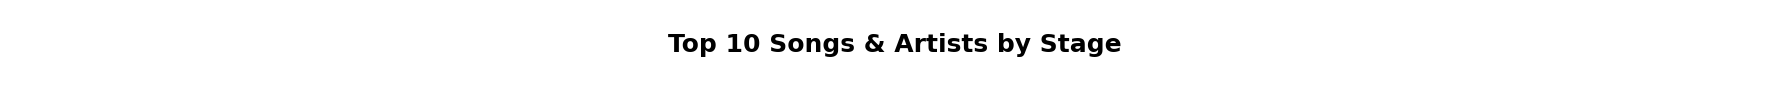

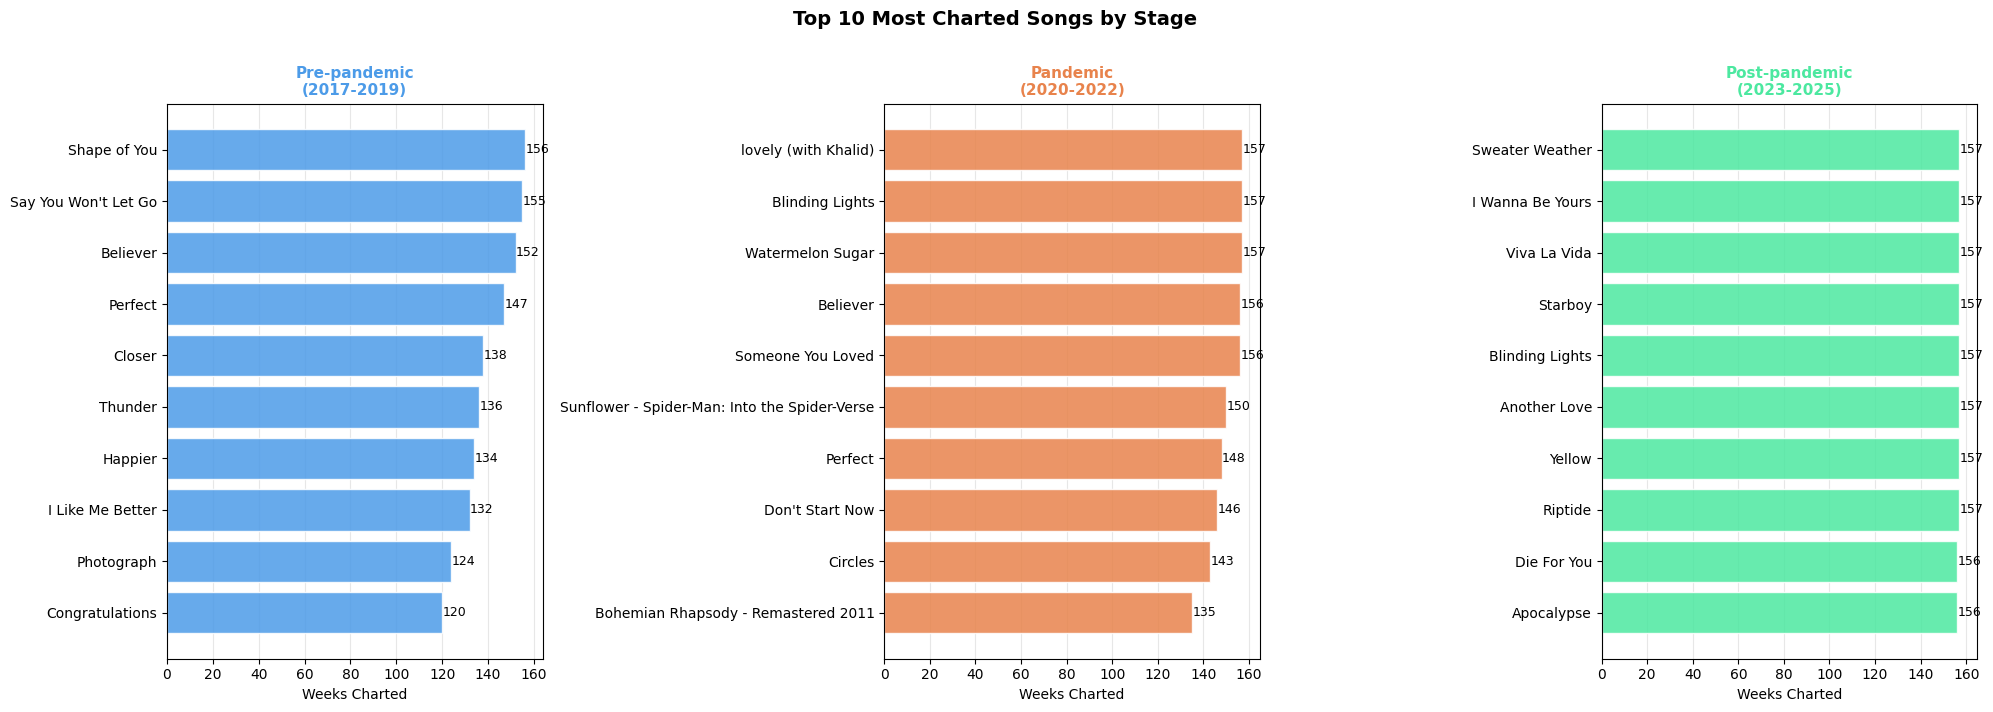

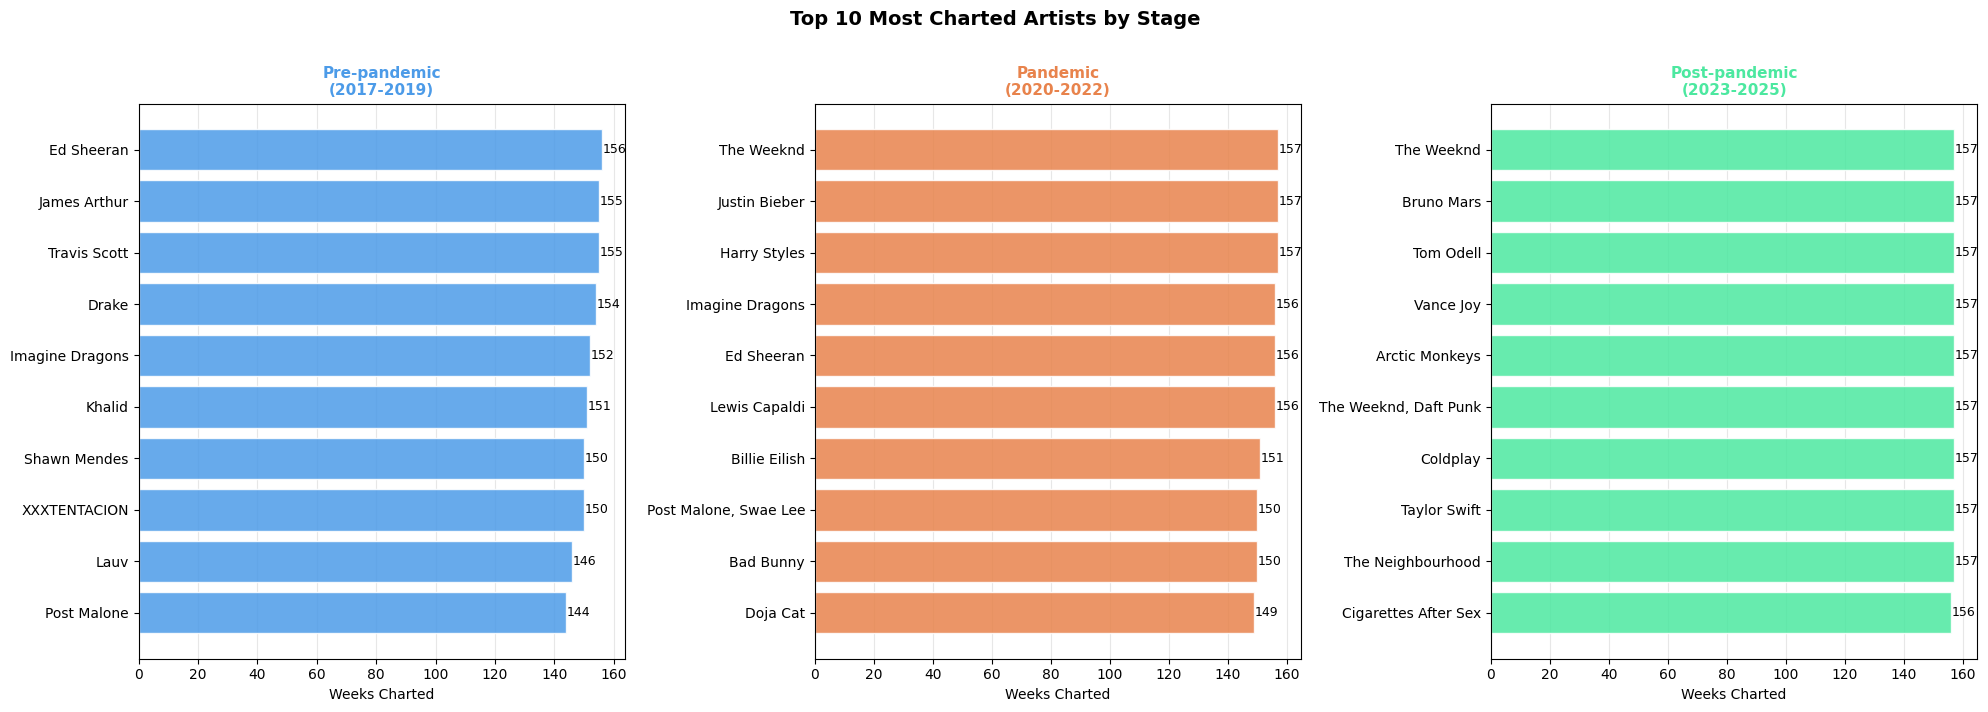

In [31]:
fig_title, ax_title = plt.subplots(figsize=(18, 1))
ax_title.text(0.5, 0.5, 'Top 10 Songs & Artists by Stage',
              ha='center', va='center', fontsize=18, fontweight='bold',
              transform=ax_title.transAxes)
ax_title.axis('off')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, stage, label, color in zip(axes, STAGE_ORDER, STAGE_LABELS, COLORS):
    top_songs = (df[df['Stage'] == stage]
                 .groupby('Title')['Week_Label']
                 .nunique()
                 .reset_index()
                 .rename(columns={'Week_Label': 'Weeks_Charted'})
                 .sort_values('Weeks_Charted', ascending=False)
                 .head(10)
                 .sort_values('Weeks_Charted'))  # ascending for horizontal bar

    ax.barh(top_songs['Title'], top_songs['Weeks_Charted'],
            color=color, alpha=0.85, edgecolor='white')
    for i, v in enumerate(top_songs['Weeks_Charted']):
        ax.text(v + 0.2, i, str(v), va='center', fontsize=9)
    ax.set_title(label, fontweight='bold', fontsize=11, color=color)
    ax.set_xlabel('Weeks Charted')
    ax.grid(axis='x', alpha=0.3)
    ax.set_axisbelow(True)

plt.suptitle('Top 10 Most Charted Songs by Stage', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── Plot: Top 10 artists per stage ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, stage, label, color in zip(axes, STAGE_ORDER, STAGE_LABELS, COLORS):
    top_artists = (df[df['Stage'] == stage]
                   .groupby('Artists_All')['Week_Label']
                   .nunique()
                   .reset_index()
                   .rename(columns={'Week_Label': 'Weeks_Charted'})
                   .sort_values('Weeks_Charted', ascending=False)
                   .head(10)
                   .sort_values('Weeks_Charted'))

    ax.barh(top_artists['Artists_All'], top_artists['Weeks_Charted'],
            color=color, alpha=0.85, edgecolor='white')
    for i, v in enumerate(top_artists['Weeks_Charted']):
        ax.text(v + 0.2, i, str(v), va='center', fontsize=9)
    ax.set_title(label, fontweight='bold', fontsize=11, color=color)
    ax.set_xlabel('Weeks Charted')
    ax.grid(axis='x', alpha=0.3)
    ax.set_axisbelow(True)

plt.suptitle('Top 10 Most Charted Artists by Stage', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()